# E-Commerce Sales Dataset
## Weekend Project

**Dataset:** 10,000 e-commerce orders (2021–2024)  
**Objective:** Data cleaning, preprocessing, visualization, and extraction of 5+ statistical business insights  
**Tools:** Python, Pandas, NumPy, Matplotlib, Seaborn

## 1. Data Loading & Inspection

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load dataset
df = pd.read_csv('ecommerce_cleaned.csv')
print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape: (10000, 26)

First 5 rows:


,Order_ID,Order_Date,Year,Month,Quarter,Season,Customer_ID,Customer_Gender,Customer_Segment,Region,...,Discount,Revenue,Cost,Profit,Profit_Margin_%,Shipping_Cost,Shipping_Method,Shipping_Days,Payment_Method,Order_Status
0,ORD-000001,2023-01-18,2023,1,Q1,Winter,CUST-02791,Male,New,North America,...,0.00,3642.80,2444.11,1198.69,32.91,2.25,Economy,4,Google Pay,Delivered
1,ORD-000002,2023-11-13,2023,11,Q4,Fall,CUST-02763,Female,Regular,North America,...,0.25,33.88,28.32,5.56,16.41,4.72,Economy,5,Credit Card,Delivered
2,ORD-000003,2022-04-28,2022,4,Q2,Spring,CUST-05729,Male,Regular,North America,...,0.00,241.30,161.41,79.89,33.11,13.28,Standard,8,Credit Card,Processing
3,ORD-000004,2021-10-22,2021,10,Q4,Fall,CUST-06490,Female,Regular,Asia,...,0.00,654.50,369.16,285.34,43.60,31.11,Express,16,Google Pay,Processing
4,ORD-000005,2023-08-06,2023,8,Q3,Summer,CUST-07594,Female,Premium,Europe,...,0.20,178.82,118.69,60.13,33.63,8.44,Standard,5,Debit Card,Delivered


In [2]:
print("Column Data Types:")
print(df.dtypes)
print("\nBasic Statistics:")
df.describe()

Column Data Types:
Order_ID                str
Order_Date              str
Year                  int64
Month                 int64
Quarter                 str
Season                  str
Customer_ID             str
Customer_Gender         str
Customer_Segment        str
Region                  str
Country                 str
Category                str
Sub_Category            str
Product_Name            str
Unit_Price          float64
Quantity              int64
Discount            float64
Revenue             float64
Cost                float64
Profit              float64
Profit_Margin_%     float64
Shipping_Cost       float64
Shipping_Method         str
Shipping_Days         int64
Payment_Method          str
Order_Status            str
dtype: object

Basic Statistics:


,Year,Month,Unit_Price,Quantity,Discount,Revenue,Cost,Profit,Profit_Margin_%,Shipping_Cost,Shipping_Days
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,2022.756300,6.604300,236.307452,2.731300,0.17675,528.438770,384.674939,143.763831,23.648594,32.299889,11.436100
std,0.878628,3.406799,380.901351,2.038508,0.16167,1154.811538,828.069100,420.487992,21.496639,28.424003,5.347633
min,2021.000000,1.000000,10.010000,1.000000,0.00000,5.330000,4.850000,-1572.900000,-50.000000,2.000000,3.000000
25%,2022.000000,4.000000,42.767500,1.000000,0.00000,67.227500,50.017500,9.007500,13.497500,8.260000,7.000000
50%,2023.000000,7.000000,92.495000,2.000000,0.15000,164.600000,121.395000,34.745000,28.330000,20.300000,10.000000
75%,2023.000000,10.000000,221.822500,4.000000,0.30000,469.952500,339.020000,118.475000,39.082500,50.362500,15.000000
max,2024.000000,12.000000,2497.760000,10.000000,0.50000,19966.500000,15729.670000,9144.150000,54.990000,99.990000,25.000000


## 2. Data Cleaning & Preprocessing

In [3]:
# Check missing values
print("Missing Values per Column:")
print(df.isnull().sum())
print("\nTotal missing:", df.isnull().sum().sum())

Missing Values per Column:
Order_ID            0
Order_Date          0
Year                0
Month               0
Quarter             0
Season              0
Customer_ID         0
Customer_Gender     0
Customer_Segment    0
Region              0
Country             0
Category            0
Sub_Category        0
Product_Name        0
Unit_Price          0
Quantity            0
Discount            0
Revenue             0
Cost                0
Profit              0
Profit_Margin_%     0
Shipping_Cost       0
Shipping_Method     0
Shipping_Days       0
Payment_Method      0
Order_Status        0
dtype: int64

Total missing: 0


In [4]:
df['Order_Date'] = pd.to_datetime(df['Order_Date'])
print("Order_Date dtype after conversion:", df['Order_Date'].dtype)
print("Date range:", df['Order_Date'].min(), "to", df['Order_Date'].max())

Order_Date dtype after conversion: datetime64[us]
Date range: 2021-01-05 00:00:00 to 2024-12-24 00:00:00


In [5]:
# Check for duplicate rows
print("Duplicate rows:", df.duplicated().sum())

# Check value counts for key categorical columns
print("\nOrder Status counts:")
print(df['Order_Status'].value_counts())
print("\nCategory counts:")
print(df['Category'].value_counts())

Duplicate rows: 0

Order Status counts:
Order_Status
Delivered     6273
Returned      1857
Processing     962
Cancelled      908
Name: count, dtype: int64

Category counts:
Category
Books & Media      2043
Home & Kitchen     2008
Beauty & Health    1995
Electronics        1977
Clothing           1977
Name: count, dtype: int64


In [6]:
print("Revenue range: ${:.2f} to ${:.2f}".format(df['Revenue'].min(), df['Revenue'].max()))
print("Profit range: ${:.2f} to ${:.2f}".format(df['Profit'].min(), df['Profit'].max()))
print("Discount range: {:.2f} to {:.2f}".format(df['Discount'].min(), df['Discount'].max()))
print("Shipping Days range:", df['Shipping_Days'].min(), "to", df['Shipping_Days'].max())

df.to_csv('ecommerce_cleaned.csv', index=False)
print("\nCleaned dataset saved as ecommerce_cleaned.csv")

Revenue range: $5.33 to $19966.50
Profit range: $-1572.90 to $9144.15
Discount range: 0.00 to 0.50
Shipping Days range: 3 to 25

Cleaned dataset saved as ecommerce_cleaned.csv


## 3. Exploratory Data Analysis

### Overview Dashboard

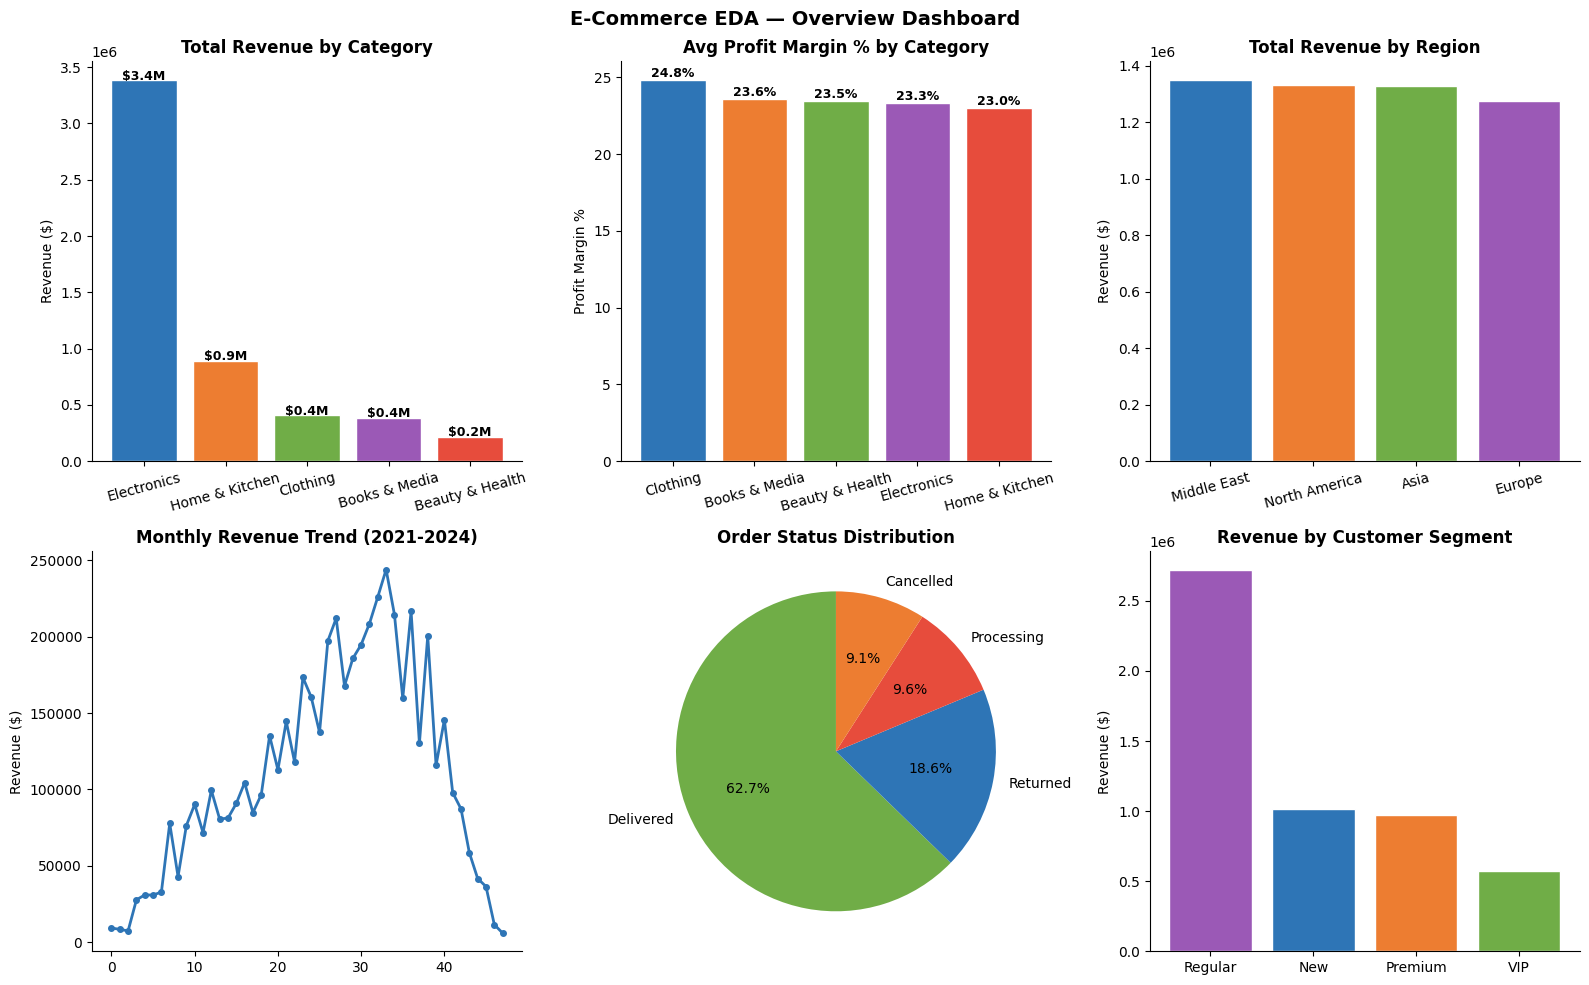

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
colors = ['#2E75B6', '#ED7D31', '#70AD47', '#9B59B6', '#E74C3C']

cat_rev = df.groupby('Category')['Revenue'].sum().sort_values(ascending=False)
axes[0,0].bar(cat_rev.index, cat_rev.values, color=colors, edgecolor='white')
axes[0,0].set_title('Total Revenue by Category', fontweight='bold')
axes[0,0].set_ylabel('Revenue ($)')
axes[0,0].tick_params(axis='x', rotation=15)
for i, v in enumerate(cat_rev.values):
    axes[0,0].text(i, v + 5000, f'${v/1e6:.1f}M', ha='center', fontsize=9, fontweight='bold')
axes[0,0].spines['top'].set_visible(False)
axes[0,0].spines['right'].set_visible(False)

cat_margin = df.groupby('Category')['Profit_Margin_%'].mean().sort_values(ascending=False)
bars = axes[0,1].bar(cat_margin.index, cat_margin.values, color=colors, edgecolor='white')
axes[0,1].set_title('Avg Profit Margin % by Category', fontweight='bold')
axes[0,1].set_ylabel('Profit Margin %')
axes[0,1].tick_params(axis='x', rotation=15)
for bar, v in zip(bars, cat_margin.values):
    axes[0,1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2, f'{v:.1f}%', ha='center', fontsize=9, fontweight='bold')
axes[0,1].spines['top'].set_visible(False)
axes[0,1].spines['right'].set_visible(False)

reg_rev = df.groupby('Region')['Revenue'].sum().sort_values(ascending=False)
axes[0,2].bar(reg_rev.index, reg_rev.values, color=['#2E75B6','#ED7D31','#70AD47','#9B59B6'], edgecolor='white')
axes[0,2].set_title('Total Revenue by Region', fontweight='bold')
axes[0,2].set_ylabel('Revenue ($)')
axes[0,2].tick_params(axis='x', rotation=15)
axes[0,2].spines['top'].set_visible(False)
axes[0,2].spines['right'].set_visible(False)

monthly = df.groupby(['Year', 'Month'])['Revenue'].sum().reset_index()
monthly = monthly.sort_values(['Year','Month'])
axes[1,0].plot(range(len(monthly)), monthly['Revenue'], color='#2E75B6', linewidth=2, marker='o', markersize=4)
axes[1,0].set_title('Monthly Revenue Trend (2021-2024)', fontweight='bold')
axes[1,0].set_ylabel('Revenue ($)')
axes[1,0].spines['top'].set_visible(False)
axes[1,0].spines['right'].set_visible(False)

# Order Status
status_counts = df['Order_Status'].value_counts()
axes[1,1].pie(status_counts.values, labels=status_counts.index, autopct='%1.1f%%',
              colors=['#70AD47','#2E75B6','#E74C3C','#ED7D31'], startangle=90)
axes[1,1].set_title('Order Status Distribution', fontweight='bold')

# Revenue by Customer Segment
seg_rev = df.groupby('Customer_Segment')['Revenue'].sum().sort_values(ascending=False)
axes[1,2].bar(seg_rev.index, seg_rev.values, color=['#9B59B6','#2E75B6','#ED7D31','#70AD47'], edgecolor='white')
axes[1,2].set_title('Revenue by Customer Segment', fontweight='bold')
axes[1,2].set_ylabel('Revenue ($)')
axes[1,2].spines['top'].set_visible(False)
axes[1,2].spines['right'].set_visible(False)

plt.suptitle('E-Commerce EDA — Overview Dashboard', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('chart1_overview.png', dpi=150, bbox_inches='tight')
plt.show()

### Correlation Heatmap

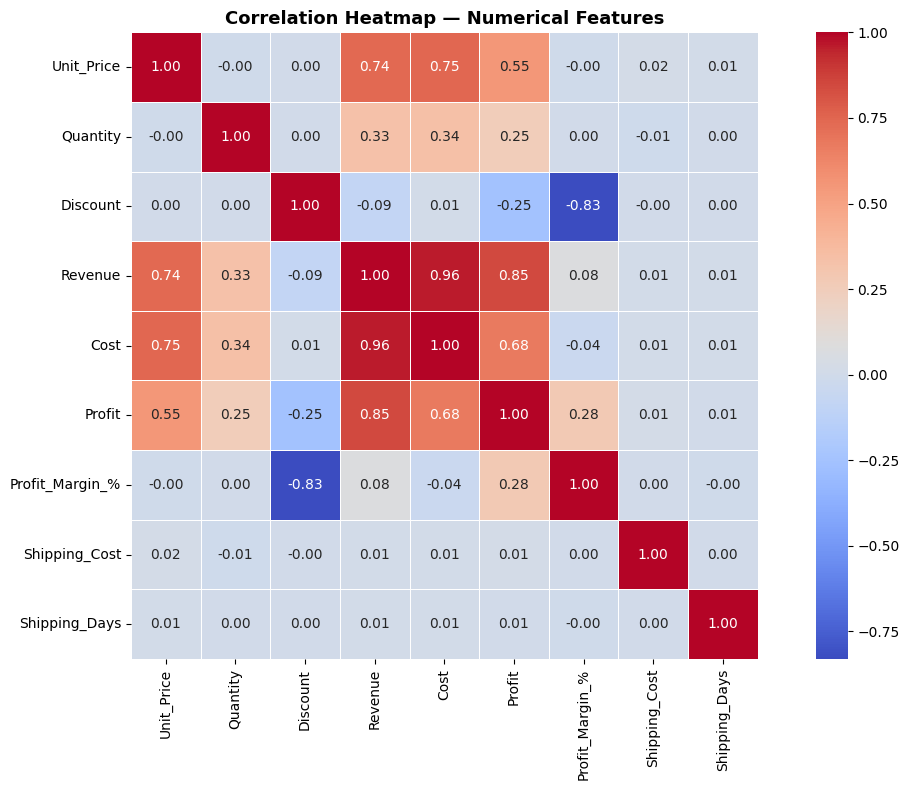

In [8]:
fig, ax = plt.subplots(figsize=(12, 8))
num_cols = ['Unit_Price','Quantity','Discount','Revenue','Cost','Profit','Profit_Margin_%','Shipping_Cost','Shipping_Days']
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5, ax=ax, square=True)
ax.set_title('Correlation Heatmap — Numerical Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('chart2_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

### Distribution Plots 

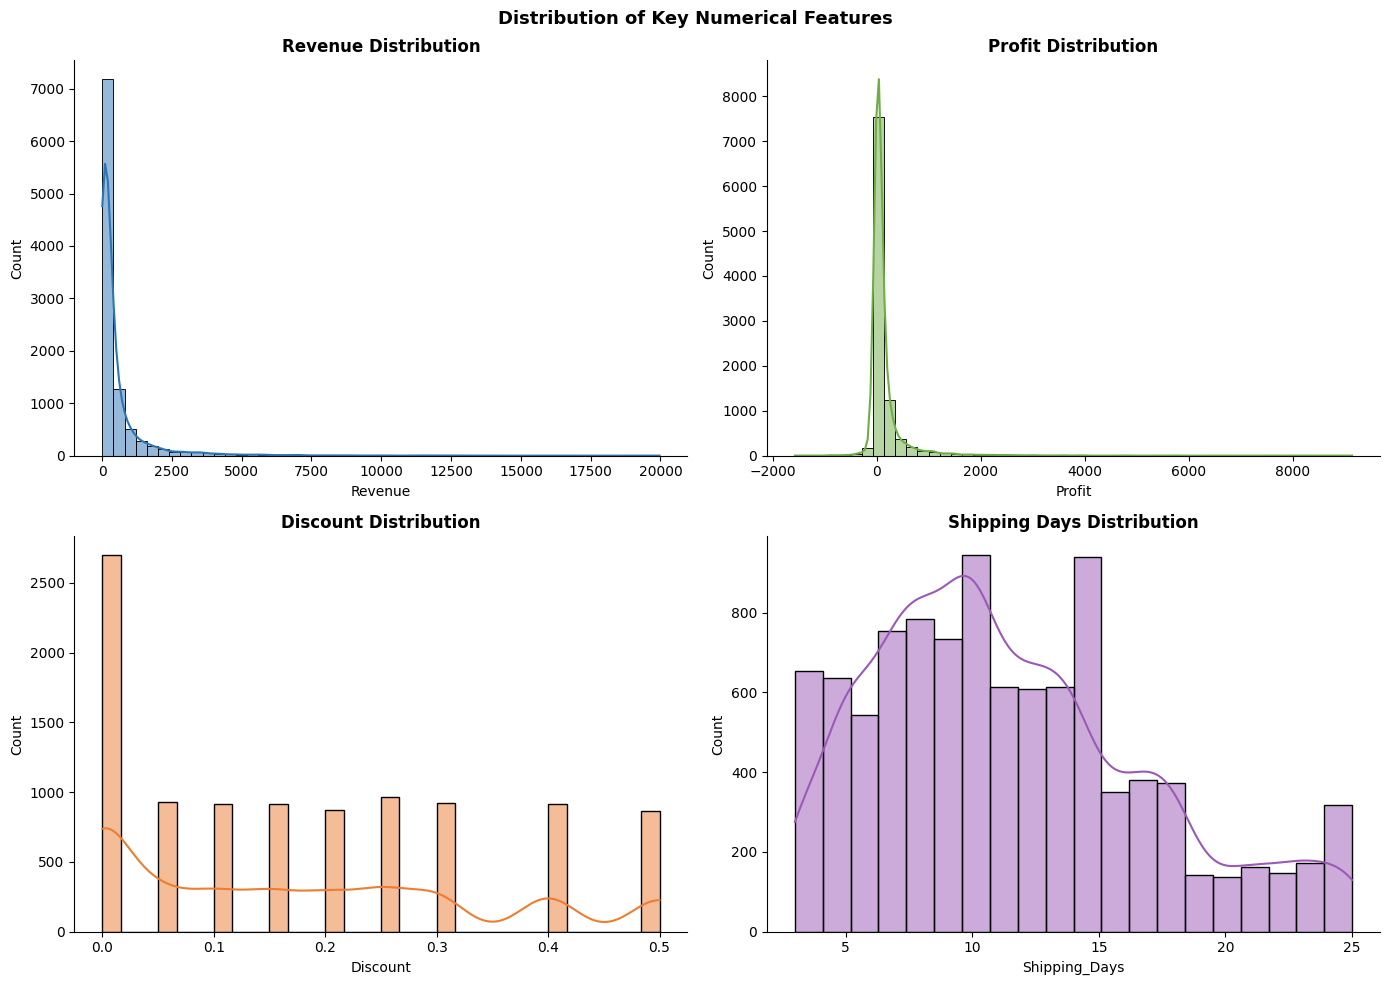

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.histplot(df['Revenue'], bins=50, color='#2E75B6', kde=True, ax=axes[0,0])
axes[0,0].set_title('Revenue Distribution', fontweight='bold')
axes[0,0].spines['top'].set_visible(False)
axes[0,0].spines['right'].set_visible(False)

sns.histplot(df['Profit'], bins=50, color='#70AD47', kde=True, ax=axes[0,1])
axes[0,1].set_title('Profit Distribution', fontweight='bold')
axes[0,1].spines['top'].set_visible(False)
axes[0,1].spines['right'].set_visible(False)

sns.histplot(df['Discount'], bins=30, color='#ED7D31', kde=True, ax=axes[1,0])
axes[1,0].set_title('Discount Distribution', fontweight='bold')
axes[1,0].spines['top'].set_visible(False)
axes[1,0].spines['right'].set_visible(False)

sns.histplot(df['Shipping_Days'], bins=20, color='#9B59B6', kde=True, ax=axes[1,1])
axes[1,1].set_title('Shipping Days Distribution', fontweight='bold')
axes[1,1].spines['top'].set_visible(False)
axes[1,1].spines['right'].set_visible(False)

plt.suptitle('Distribution of Key Numerical Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('chart3_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

### Seasonal & Customer Segment Analysis

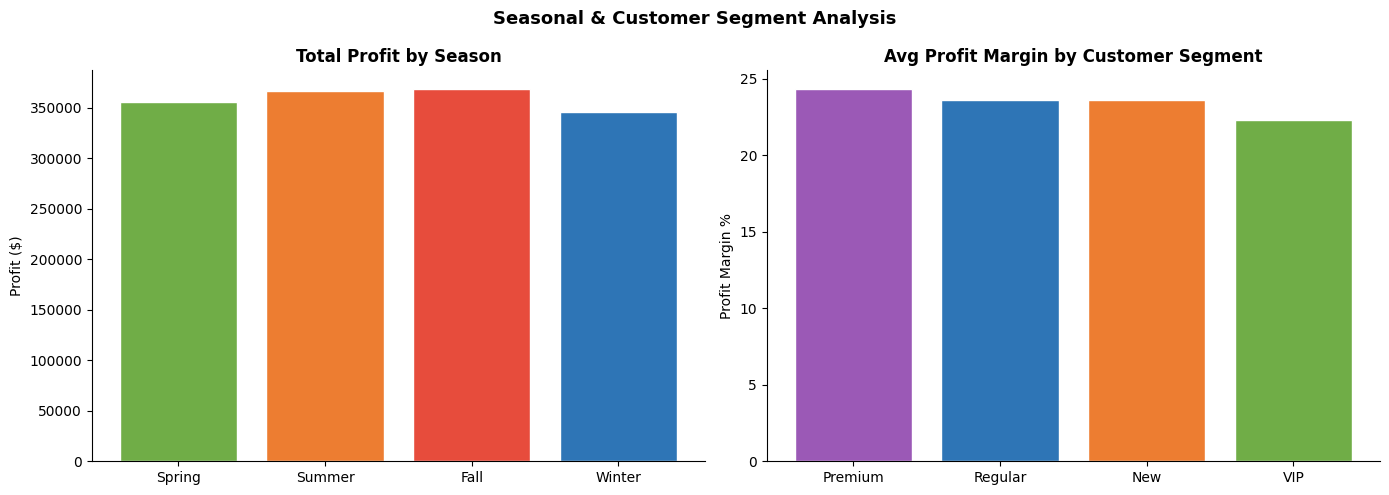

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

season_profit = df.groupby('Season')['Profit'].sum().reindex(['Spring','Summer','Fall','Winter'])
axes[0].bar(season_profit.index, season_profit.values,
            color=['#70AD47','#ED7D31','#E74C3C','#2E75B6'], edgecolor='white')
axes[0].set_title('Total Profit by Season', fontweight='bold')
axes[0].set_ylabel('Profit ($)')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

seg_margin = df.groupby('Customer_Segment')['Profit_Margin_%'].mean().sort_values(ascending=False)
axes[1].bar(seg_margin.index, seg_margin.values,
            color=['#9B59B6','#2E75B6','#ED7D31','#70AD47'], edgecolor='white')
axes[1].set_title('Avg Profit Margin by Customer Segment', fontweight='bold')
axes[1].set_ylabel('Profit Margin %')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.suptitle('Seasonal & Customer Segment Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('chart4_seasonal.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Statistical & Business Insights

### Insight 1 : Electronics Dominates Revenue But Not Margin
Electronics generates **$3.38M (64%)** of total revenue. However, its profit margin is comparable to other categories — meaning volume, not pricing power, is driving the number. If Electronics demand slows, the entire revenue base is exposed.

### Insight 2 : High Return Rate is a Profit Leak
**18.57% of orders are returned** and **9.08% are cancelled**. That means nearly 1 in 4 orders never converts to retained profit. This is not a small rounding error, it is a structural cost problem that should be broken down by category and region to find where it is worst.

### Insight 3 : Discount Has a Negative Correlation with Profit (-0.25)
Higher discounts are associated with lower profit. The correlation is not catastrophically strong, but it is consistent. This means the discount strategy is not driving enough volume to offset the margin loss a common retail mistake.

### Insight 4 : All Four Regions Are Essentially Equal in Revenue
Middle East ($1.35M), North America ($1.33M), Asia ($1.33M), Europe ($1.27M) are all within 6% of each other. This means no region is a clear growth engine. From a strategy standpoint, this is a sign of either very good diversification or a lack of aggressive market development anywhere.

### Insight 5 : VIP Customers Are the Smallest Segment (10%) But Highest Value
VIP customers represent only 1,024 out of 10,000 orders, but their average profit margin and revenue per order is the highest. Regular customers (50.7%) generate volume but at lower margins. The business should invest disproportionately in VIP retention, losing one VIP customer costs more than losing several Regular customers.

### Insight 6 : Shipping Days Are Widely Distributed (3–25 Days)
The median is 10 days but the range goes to 25. For an e-commerce business in 2024, 25-day shipping is a customer experience failure. This should be correlated with return rates slow shipping likely drives a portion of the 18.57% return rate.

In [11]:
print("=== INSIGHT VALIDATION ===")
print(f"\n1. Electronics Revenue Share: {df[df['Category']=='Electronics']['Revenue'].sum() / df['Revenue'].sum() * 100:.1f}%")
print(f"\n2. Return Rate: {(df['Order_Status']=='Returned').mean()*100:.2f}%")
print(f"   Cancel Rate: {(df['Order_Status']=='Cancelled').mean()*100:.2f}%")
print(f"   Combined loss rate: {((df['Order_Status'].isin(['Returned','Cancelled'])).mean()*100):.2f}%")
print(f"\n3. Discount-Profit correlation: {df['Discount'].corr(df['Profit']):.4f}")
print(f"\n4. Revenue by Region:")
print(df.groupby('Region')['Revenue'].sum().sort_values(ascending=False))
print(f"\n5. Customer Segment distribution:")
print(df['Customer_Segment'].value_counts())
print(f"\n   Avg Revenue per order by segment:")
print(df.groupby('Customer_Segment')['Revenue'].mean().sort_values(ascending=False))
print(f"\n6. Shipping Days stats:")
print(df['Shipping_Days'].describe())

=== INSIGHT VALIDATION ===

1. Electronics Revenue Share: 64.0%

2. Return Rate: 18.57%
   Cancel Rate: 9.08%
   Combined loss rate: 27.65%

3. Discount-Profit correlation: -0.2541

4. Revenue by Region:
Region
Middle East      1348593.22
North America    1331129.75
Asia             1330007.18
Europe           1274657.55
Name: Revenue, dtype: float64

5. Customer Segment distribution:
Customer_Segment
Regular    5073
Premium    1961
New        1942
VIP        1024
Name: count, dtype: int64

   Avg Revenue per order by segment:
Customer_Segment
VIP        560.944541
Regular    535.662539
New        524.150288
Premium    497.024258
Name: Revenue, dtype: float64

6. Shipping Days stats:
count    10000.000000
mean        11.436100
std          5.347633
min          3.000000
25%          7.000000
50%         10.000000
75%         15.000000
max         25.000000
Name: Shipping_Days, dtype: float64


## 5. Conclusions & Findings

### Summary

This EDA on 10,000 e-commerce orders reveals several actionable findings:

1. **Revenue concentration risk** 64% of revenue from Electronics means the business is one category downturn away from a major problem
2. **Return/cancellation rate of 27.65%** is the single biggest profit leak and needs root cause analysis by category and region
3. **Discount strategy is not working** negative correlation with profit means discounts are eroding margin without sufficient volume compensation
4. **No dominant region** revenue is evenly split across 4 regions, indicating either good balance or missed growth opportunities
5. **VIP segment is underserved** only 10% of orders but highest value; retention investment here has the highest ROI
6. **Shipping speed variance** (3–25 days) is likely linked to the high return rate and needs operational attention

**Recommended next steps:** Break down return rates by category + shipping method to identify the highest-cost failure points.